# 01 — Baseline QLoRA Fine-tuning

Establish a QLoRA fine-tuning baseline on `meta-llama/Llama-3.2-1B-Instruct` before any pruning, R-tuning, or unlearning.

**Sequence**

1. Setup & config
2. Data loading (interactive MinIO picker)
3. Model loading with Unsloth (4-bit) + QLoRA adapters
4. Training (SFTTrainer)
5. Evaluation — perplexity on eval set
6. Inference test — all mental-health prompt batteries
7. Save model via MLflow + GGUF export

Logs to MLflow under experiment `burnit-bg-experiments`, run tagged `experiment=baseline`.


In [ ]:
# ###### Colab bootstrap ######
# On Colab the [experiments] extras pulls both requirements_package.txt and
# requirements_experiments.txt in one pip command — single source of truth lives
# in setup.py's extras_require. Then bootstrap() loads Colab Secrets into
# os.environ and brings up Tailscale so *.ts.net hostnames are reachable.
# Locally bootstrap() just loads .env and checks the tailnet — no installs.
#
# Required Colab Secrets (key icon → Add new secret → toggle "Notebook access"):
#   TAILSCALE_AUTHKEY   – from https://login.tailscale.com/admin/settings/keys
#   MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME, MLFLOW_TRACKING_INSECURE_TLS
#   MINIO_ENDPOINT / MINIO_ACCESS_KEY / MINIO_SECRET_KEY / MINIO_SECURE
#   HF_TOKEN
import os, subprocess, sys
IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "burnit_bg[experiments] @ git+https://github.com/kirilyotov/BurnIT-BG.git",
    ])
    # Colab ships a broken wandb 0.x where `wandb.proto.wandb_telemetry_pb2`
    # is missing the `Imports` symbol, which trl imports unconditionally at
    # `from trl import SFTTrainer`. We don't use wandb (report_to=[]), so the
    # cleanest fix is to uninstall it before trl is imported anywhere.
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "wandb"])
    # PEFT 0.17+ requires torchao >= 0.16.0 for is_torchao_available()
    # checks during non-4bit LoRA setup. Colab ships 0.10.0 → ImportError
    # at apply_lora() time. Upgrade here, before any PEFT code runs.
    subprocess.call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "torchao"])

# Unsloth must be imported BEFORE transformers/peft/trl for its monkey-patches
# to register — otherwise it warns "Unsloth should be imported before [...]"
# and silently skips the fast kernels (~2x slowdown). No-ops gracefully on
# machines without unsloth (CPU dev boxes).
try:
    import unsloth  # noqa: F401
except Exception:
    pass

from utils.colab import bootstrap
bootstrap()


In [2]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"Device: {props.name}")
    print(f"VRAM:   {props.total_memory / 1024**3:.2f} GB")
    print(f"Compute capability: {props.major}.{props.minor}")


CUDA available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM:   3.68 GB
Compute capability: 8.6


## 1. Setup & config

In [ ]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'data_platform').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from data_platform.common import set_env
from data_platform.storage import MinioStorage

from experiments.shared.mlflow_utils import setup_run, log_responses, stage, log_training_curves
from experiments.shared.judge_utils import judge_and_log, JudgePanel
from experiments.shared.mlflow_judges import get_scorers, batteries_to_eval_dataset, reset_cache as reset_judge_cache
from experiments.shared.prompt_registry import register_burnit_prompts
from experiments.shared.inference_utils import (
    run_full_test_battery,
    TEST_PROMPTS_IN_DOMAIN, TEST_PROMPTS_OUT_OF_DOMAIN, TEST_PROMPTS_EDGE,
    format_prompt,
)
from experiments.shared.model_utils import (
    DEFAULT_MODEL_NAME, load_model_unsloth, apply_qlora, apply_dora, apply_lora,
    count_trainable_params, cuda_device_info, default_repo_for, push_to_hf,
)
from experiments.shared.eval_utils import (
    compute_perplexity, benchmark_speed, vram_snapshot,
    compute_bertscore, compute_rouge,
    plot_train_eval_loss, plot_grad_norm, plot_metric_scorecard, overfit_summary,
    per_epoch_metrics_table, plot_per_epoch_metrics,
)
from experiments.shared.notebook_utils import log_executed_notebook
from experiments.shared.dataset_utils import (
    load_alpaca_dataset, dataset_statistics, alpaca_to_prompt,
)
from experiments.shared.dataset_browser import list_datasets, pick_dataset, download_dataset, resolve
from experiments.shared.dataset_loader import get_dataset, LoadedDataset
from transformers import EarlyStoppingCallback


In [ ]:
# ===== TOP-OF-NOTEBOOK CONFIG (override via env or edit here) =====
# Copy this notebook + change DATASET_NAME / DATASET_SOURCE to retarget it
# at a different dataset without touching any cell below. Source values:
#   "registry" — looks up ids in experiments.shared.datasets_registry (default)
#   "hf-bucket" — pulls a file from a HF Bucket (needs file=... in get_dataset)
#   "hf"       — HuggingFace Datasets Hub
#   "minio"    — S3-compatible bucket via dataset_browser
#   "local"    — filesystem dir with train.jsonl + eval.jsonl
# Registry ids are typo-safe — use `Datasets.<NAME>.value.id` instead of strings.

from experiments.shared.datasets_registry import Datasets, MENTAL_HEALTH_ALL

MENTALHEALTH: tuple[str, ...] = (
     Datasets.CHITANKA_BG.value.id,
    Datasets.MH_COUNSELING_BG.value.id,
)

MODEL_NAME          = os.getenv("MODEL_NAME",       'meta-llama/Llama-3.2-1B-Instruct')
DATASET_NAME        = os.getenv("DATASET_NAME")   or ",".join(MENTALHEALTH)
DATASET_SOURCE      = os.getenv("DATASET_SOURCE",   'registry')
DATASET_SUBSET      = os.getenv("DATASET_SUBSET",   None)  # for multi-config HF datasets
TRAIN_EPOCHS        = int(os.getenv("TRAIN_EPOCHS", "1"))
EARLY_STOP_PATIENCE = int(os.getenv("EARLY_STOP_PATIENCE", "2"))
_max_steps_env      = os.getenv("MAX_STEPS")
MAX_STEPS           = int(_max_steps_env) if _max_steps_env else None
METRIC_FOR_BEST     = os.getenv("METRIC_FOR_BEST_MODEL", 'eval_loss')
print(f"[config] model={MODEL_NAME}  dataset={DATASET_NAME} ({DATASET_SOURCE})  "
      f"epochs={TRAIN_EPOCHS}  early_stop_patience={EARLY_STOP_PATIENCE}")

# Mixed-precision auto-detect.
# torch.cuda.is_bf16_supported() returns True on T4 (Turing 7.5) where bf16
# *training* actually fails — SFTConfig/TrainingArguments reject bf16=True on
# non-Ampere GPUs. Compute capability >= 8.0 is the only reliable signal.
import torch
def _has_bf16_training():
    if not torch.cuda.is_available():
        return False
    major, _ = torch.cuda.get_device_capability(0)
    return major >= 8
USE_BF16 = _has_bf16_training()
USE_FP16 = bool(torch.cuda.is_available() and not USE_BF16)
# Thread this through load_model_unsloth(..., dtype=MODEL_DTYPE) so the base
# model and the trainer's AMP path agree on dtype. Mismatch triggers
# "_amp_foreach_non_finite_check_and_unscale_cuda not implemented for BFloat16".
MODEL_DTYPE = torch.bfloat16 if USE_BF16 else (torch.float16 if USE_FP16 else torch.float32)
print(f"[config] USE_BF16={USE_BF16} USE_FP16={USE_FP16} MODEL_DTYPE={MODEL_DTYPE}")

# Per-notebook identity tags. METHOD is constant for this notebook; MODEL_TAG
# is the sanitised basename of MODEL_NAME; MLFLOW_EXPERIMENT groups runs by
# method+model so each combination has its own MLflow experiment.
METHOD = "qlora"
MODEL_TAG = MODEL_NAME.split("/")[-1].lower().replace("_", "-")
MLFLOW_EXPERIMENT = f"{METHOD}_{MODEL_TAG}"
print(f"[config] METHOD={METHOD}  MODEL_TAG={MODEL_TAG}  "
      f"MLFLOW_EXPERIMENT={MLFLOW_EXPERIMENT}")

# HuggingFace branch / repo identity. Convention used across all BurnIT-BG
# experiments: ONE model repo per project, ONE branch per (experiment_type,
# algorithm, model, dataset) combination — so apples-to-apples comparison
# across iterations stays clean.
from experiments.shared.model_utils import hf_branch_name

EXPERIMENT_TYPE = "finetune"
HF_REPO = os.getenv("HF_MODEL_REPO", "kiplayo/BurnIT-BG")
HF_BRANCH = os.getenv(
    "HF_REVISION",
    hf_branch_name(EXPERIMENT_TYPE, METHOD, MODEL_NAME, DATASET_NAME),
)
print(f"[hf] repo={HF_REPO}  branch={HF_BRANCH}")


In [ ]:
# MLflow needs to be in this cell's scope: mlflow.genai.evaluate (below)
# and the model-save block both reference it directly.
import mlflow
set_env(quiet=True)
# Throttle mlflow.genai.evaluate's scorer thread pool BEFORE the panel runs.
# Default is 4 parallel scorers; with our 3-call panel that'd be 12 concurrent
# requests to a 40 RPM NVIDIA endpoint — instant 429 storm. We use 2 workers
# and let the per-model RpmBucket in NvidiaChatClient pace the wire.
os.environ.setdefault("MLFLOW_GENAI_EVAL_MAX_SCORER_WORKERS", "2")
# Bump the urllib3 connection pool so concurrent MLflow log_metric / log_artifact
# calls during mlflow.genai.evaluate don't trip the "Connection pool is full,
# discarding connection" warning (default pool size is 10 — too small for the
# evaluator's burst of writes back to the MLflow tracking server).
try:
    import urllib3 as _u3
    _u3.PoolManager(num_pools=10, maxsize=50)  # warms up larger pools
    import requests.adapters as _ra
    _ra.DEFAULT_POOLSIZE = 50
except Exception:
    pass
# Optional per-process RPM ceiling (per NVIDIA model key). Free tier is ~40
# RPM per key; we default to 30 to leave headroom for retries. Override via
# the NVIDIA_DEFAULT_RPM env var in Colab Secrets if you have a higher quota.
os.environ.setdefault("NVIDIA_DEFAULT_RPM", "30")

tracking, tags, run_name = setup_run(
    experiment='baseline',
    model=MODEL_NAME,    # was DEFAULT_MODEL_NAME — show the actually-used model in MLflow tags
    stage="experiment",
    mlflow_experiment_name=MLFLOW_EXPERIMENT,
)
print(f"run_name = {run_name}")
print(f"tags     = {tags}")
print(f"machine  = {cuda_device_info()}")


## 2. Data loading

Default: trains on every dataset in `MENTAL_HEALTH_ALL` from `experiments.shared.datasets_registry` (currently chitanka-bg + mh-counseling-bg + kaggle-mh-conversations-bg, combined and shuffled). To use a specific dataset, set `DATASET_NAME=Datasets.<NAME>.value.id` in env, or edit the config cell.

In [6]:
# ###### Load the dataset configured at the top + register in MLflow ######
import mlflow as _mlflow

_ds = get_dataset(DATASET_NAME, source=DATASET_SOURCE, subset=DATASET_SUBSET)
train_records, eval_records = _ds.train, _ds.eval
train_stats = dataset_statistics(train_records)
eval_stats  = dataset_statistics(eval_records)
print(f"train: {len(train_records)} rows  eval: {len(eval_records)} rows  "
      f"({_ds.source}: {_ds.source_uri})")
print(train_stats)

# Register the dataset against the active run so it appears in MLflow's
# Datasets tab. If no run is active yet (the typical case here — training
# opens its own run below), we'll re-attach there.
try:
    if _mlflow.active_run():
        _mlflow.log_input(_ds.to_mlflow_input(context='train'), context='train')
        _mlflow.log_input(_ds.to_mlflow_input(context='eval'), context='eval')
        print(f"[mlflow] dataset registered: {_ds.name}")
except Exception as _ds_exc:
    print(f"[mlflow] dataset register skipped: {_ds_exc}")


train: 70015 rows  eval: 7780 rows  (registry: hf-bucket://kiplayo/data;hf-bucket://kiplayo/data;hf-bucket://kiplayo/data)
{'count': 70015, 'refusal_count': 0, 'refusal_ratio': 0.0, 'by_category': {'self-esteem': 9128, '?': 39371, 'anxiety': 4647, 'relationships': 9052, 'depression': 1645, 'stress': 5111, 'out_of_domain': 1061}, 'by_difficulty': {'moderate': 30644, '?': 39371}, 'by_source': {'chitanka:4908': 262, '?': 39371, 'chitanka:1388': 332, 'chitanka:2050': 313, 'chitanka:10109': 116, 'chitanka:2215': 234, 'chitanka:1620': 367, 'chitanka:4298': 186, 'chitanka:2610': 508, 'chitanka:1549': 295, 'chitanka:3486': 388, 'chitanka:8515': 293, 'chitanka:3621': 146, 'chitanka:1277': 218, 'chitanka:4111': 828, 'chitanka:3011': 415, 'chitanka:10108': 172, 'chitanka:4787': 279, 'chitanka:4770': 197, 'chitanka:8877': 946, 'chitanka:1621': 324, 'chitanka:11890': 255, 'chitanka:7357': 577, 'chitanka:1473': 195, 'chitanka:1618': 383, 'chitanka:11355': 452, 'chitanka:1554': 394, 'chitanka:1130': 

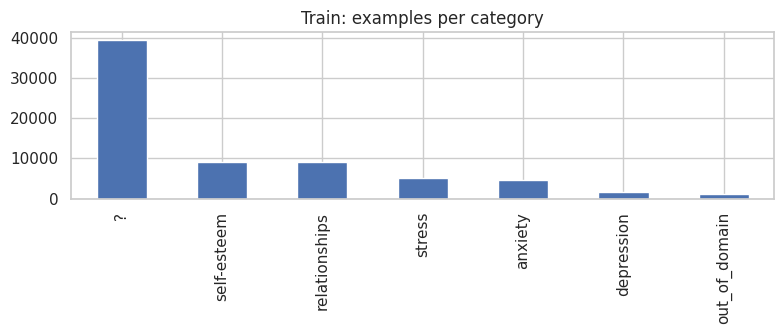

In [7]:
# Quick category distribution chart
import pandas as pd, matplotlib.pyplot as plt
cat_counts = pd.Series(train_stats["by_category"]).sort_values(ascending=False)
ax = cat_counts.plot(kind="bar", figsize=(8, 3.5), title="Train: examples per category")
plt.tight_layout(); plt.show()


## 3. Model loading

In [ ]:
HF_TOKEN = os.getenv("HF_TOKEN")
MAX_SEQ_LEN = 512

with stage(tracking, "load_model"):
    model, tokenizer = load_model_unsloth(
        MODEL_NAME,
        max_seq_length=MAX_SEQ_LEN,
        load_in_4bit=True,
        token=HF_TOKEN,
        dtype=MODEL_DTYPE,
    )
    model = apply_qlora(model, r=8, lora_alpha=16, use_gradient_checkpointing=False)
    # AMP safety net — Unsloth creates LoRA adapters in bf16 whenever
    # the GPU reports ANY bf16 support (T4 included), but fp16=True
    # in SFTConfig enables HF's GradScaler, which can't unscale bf16
    # gradients -> _amp_foreach_non_finite_check_and_unscale_cuda not
    # implemented for BFloat16. Forcing every trainable param to
    # MODEL_DTYPE (fp16 on T4) keeps the GradScaler happy. No-op if
    # the dtypes already match.
    import torch as _t
    _n_cast = 0
    if isinstance(MODEL_DTYPE, _t.dtype):
        for _p in model.parameters():
            if _p.requires_grad and _p.dtype != MODEL_DTYPE:
                _p.data = _p.data.to(MODEL_DTYPE)
                _n_cast += 1
    if _n_cast:
        print(f"[adapter_dtype] aligned {_n_cast} trainable params to {MODEL_DTYPE}")
    params = count_trainable_params(model)
    print(params)


## 4. Training

In [9]:
from datasets import Dataset

def _format(record):
    record["text"] = alpaca_to_prompt(record, eos_token=tokenizer.eos_token)
    return record

train_ds = Dataset.from_list(train_records).map(_format)
eval_ds  = Dataset.from_list(eval_records).map(_format)


Map:   0%|          | 0/70015 [00:00<?, ? examples/s]

Map:   0%|          | 0/7780 [00:00<?, ? examples/s]

Trace(trace_id=tr-9424052d622ce99076ff9e845ba1611e)

In [ ]:
from trl import SFTTrainer, SFTConfig

OUTPUT_DIR = REPO_ROOT / "tmp/experiments/baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=TRAIN_EPOCHS,
    per_device_train_batch_size=16,    # L4 24GB fits batch 16 even with vocab=128k logits
    gradient_accumulation_steps=1,    # was 2 — single fat step beats 2 micro-batches
    learning_rate=2e-4,
    warmup_ratio=0.03,
    logging_steps=5,
    save_strategy="epoch",
    # L4 has native bf16 tensor cores; HF doesn't use GradScaler in bf16
    # mode, so the Unsloth bf16-grad-buffer bug that bit us on T4 can't
    # trigger here. Pure bf16 = fastest stable mode on Ada.
    bf16=True, fp16=False,
    optim="adamw_8bit",   # BnB 8-bit Adam — better cache locality than fused on QLoRA workload
    report_to=[],
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model=METRIC_FOR_BEST,
    greater_is_better=False,
    eval_strategy="epoch",
    dataset_text_field="text",
    max_length=MAX_SEQ_LEN,
)


In [ ]:

# MLflow needs to be in this cell's scope: mlflow.genai.evaluate (below)
# and the model-save block both reference it directly.
import mlflow
with tracking.run(run_name=run_name, tags=tags):
    tracking.log_params({
        **{f"data.{k}": v for k, v in train_stats.items() if not isinstance(v, dict)},
        **{f"model.{k}": v for k, v in params.items()},
        **{f"train.{k}": getattr(training_args, k) for k in (
            "num_train_epochs","per_device_train_batch_size","gradient_accumulation_steps",
            "learning_rate","warmup_ratio","lr_scheduler_type","max_grad_norm",
        )},
        "max_seq_length": MAX_SEQ_LEN,
    })

    with stage(tracking, "train"):
        trainer = SFTTrainer(
            model=model,
            processing_class=tokenizer,
            train_dataset=train_ds,
            eval_dataset=eval_ds,
            args=training_args,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)]
)
        trainer_stats = trainer.train()

    history_steps = [h["step"] for h in trainer.state.log_history if "loss" in h]
    history_loss  = [h["loss"]  for h in trainer.state.log_history if "loss" in h]
    history_lr    = [h.get("learning_rate", 0.0) for h in trainer.state.log_history if "loss" in h]
    if history_steps:
        log_training_curves(tracking, steps=history_steps, losses=history_loss, learning_rates=history_lr, title="baseline")

    # ─── per-epoch metrics table ────────────────────────────────────────
    # Same columns SFTTrainer prints live (epoch / training_loss /
    # validation_loss / entropy / mean_token_accuracy / num_tokens),
    # snapshotted as a matplotlib table figure AND a structured MLflow
    # table artifact. Survives Colab session loss — both are persisted.
    try:
        _epoch_rows = per_epoch_metrics_table(list(trainer.state.log_history))
        if _epoch_rows:
            tracking.log_plot(
                plot_per_epoch_metrics(_epoch_rows,
                                       title=f"baseline — per-epoch metrics"),
                key=f"baseline_epoch_metrics_table",
            )
            try:
                import mlflow as _mlflow
                _mlflow.log_table(data=_epoch_rows,
                                  artifact_file=f"baseline_epoch_metrics.json")
            except Exception as _exc:
                print(f"[metrics_table] log_table skipped: {_exc}")
            print(f"[metrics_table] logged {len(_epoch_rows)} epoch rows")
        else:
            print("[metrics_table] no eval rows in trainer.state.log_history")
    except Exception as _exc:
        print(f"[metrics_table] failed: {_exc}")
    tracking.log_metrics({"final_train_loss": float(history_loss[-1]) if history_loss else 0.0})

    with stage(tracking, "evaluate"):
        ppl = compute_perplexity(model, tokenizer, [r["output"] for r in eval_records[:64]])
        tracking.log_metrics({"eval_perplexity": float(ppl)})
        print(f"eval perplexity = {ppl:.3f}")
        tracking.log_metrics({f"vram.{k}": v for k, v in vram_snapshot().items()})

    # Test prompts
    batteries = run_full_test_battery((model, tokenizer), max_new_tokens=256)
    log_responses(tracking, experiment="baseline",
                  model_checkpoint=str(OUTPUT_DIR), **batteries)
    for k, v in batteries.items():
        print(f"-- {k} --")
        for entry in v[:2]:
            print(f"  Q: {entry['prompt'][:80]}\n  A: {entry['response'][:200]}\n")

    # LLM-judge panel (Mistral quality + Llama-Guard/Nemotron safety).
    # Path A — custom panel logs judge.* metrics + a JSON artifact on this run.
    with stage(tracking, "judge"):
        judge_result = judge_and_log(tracking, experiment="baseline", batteries=batteries)
        print("judge summary:", judge_result["summary"])
    # Path B — MLflow GenAI Evaluation API (per-row Feedback in the Evaluation tab).
    with stage(tracking, "judge_mlflow_eval"):
        reset_judge_cache()
        eval_data = batteries_to_eval_dataset(batteries)
        try:
            mlflow.genai.evaluate(data=eval_data, scorers=get_scorers())
            print(f"mlflow.genai.evaluate -> {len(eval_data)} rows scored")
        except Exception as exc:
            print(f"[mlflow.genai.evaluate] skipped: {type(exc).__name__}: {exc}")

    # metric plots + scorecard
    with stage(tracking, "metrics_plots"):
        history = list(trainer.state.log_history)
        if history:
            try: tracking.log_plot(plot_train_eval_loss(history, title="baseline loss"), key="baseline_train_eval_loss")
            except Exception as exc: print(f"[plots] loss skipped: {exc}")
            try: tracking.log_plot(plot_grad_norm(history, title="baseline grad"), key="baseline_grad_norm")
            except Exception as exc: print(f"[plots] grad skipped: {exc}")
            try: tracking.log_metrics({f"overfit.{k}": v for k, v in overfit_summary(history).items() if isinstance(v, (int, float))})
            except Exception: pass
        try:
            summary = judge_result.get("summary", {})
            sc = {}
            if ppl and ppl > 0:
                sc["1/(1+ppl)"] = 1.0 / (1.0 + float(ppl))
            ov = summary.get("judge.overall_mean")
            if isinstance(ov, (int, float)):
                sc["judge_overall/5"] = ov / 5.0
            un = summary.get("judge.unsafe_count"); nt = summary.get("judge.n_total")
            if isinstance(un, (int, float)) and isinstance(nt, (int, float)) and nt > 0:
                sc["1-unsafe_rate"] = 1.0 - (un / nt)
            if sc:
                tracking.log_plot(plot_metric_scorecard(sc, title="baseline scorecard"), key="baseline_scorecard")
        except Exception as exc:
            print(f"[plots] scorecard skipped: {exc}")

    # Save via MLflow — artifact + registered model version
        # save_model — robust to PEFT-wrapped models. MLflow's
    # transformers flavor rejects PeftModelForCausalLM ("must be a
    # Pipeline / dict / path"). We save the model+tokenizer locally
    # via save_pretrained (works for PEFT and full models) and log the
    # directory as plain artifacts. If MLflow is reachable we also try
    # to register the resulting artifact under the configured name.
    with stage(tracking, "save_model"):
        import tempfile
        from pathlib import Path as _Path
        _save_dir = _Path(tempfile.mkdtemp(prefix="hf_model_save_"))
        try:
            model.save_pretrained(str(_save_dir))
            tokenizer.save_pretrained(str(_save_dir))
            mlflow.log_artifacts(str(_save_dir), artifact_path="model")
            print(f"[save] model + tokenizer logged as artifacts ({_save_dir})")
            try:
                _run_id = mlflow.active_run().info.run_id if mlflow.active_run() else None
                if _run_id:
                    mlflow.register_model(f"runs:/{_run_id}/model", "burnit-bg-baseline")
                    print(f"[save] registered as burnit-bg-baseline (version added)")
            except Exception as _reg_exc:
                print(f"[save] artifacts saved; registration skipped: {type(_reg_exc).__name__}: {_reg_exc}")
        except Exception as exc:
            print(f"[save] failed: {type(exc).__name__}: {exc}")

    # Optional GGUF export
    with stage(tracking, "gguf_export"):
        try:
            from experiments.shared.model_utils import export_gguf
            gguf_path = export_gguf(model, tokenizer, OUTPUT_DIR / "gguf", quantization="q4_k_m")
            tracking.save_data(gguf_path, artifact_path="gguf")
            print(f"[save] GGUF logged: {gguf_path}")
        except Exception as exc:
            print(f"[save] GGUF export skipped: {exc}")

    # Optional: publish to HuggingFace (set PUSH_TO_HF=1 in env/secrets)
    if os.getenv("PUSH_TO_HF", "0").lower() in ("1", "true", "yes"):
        with stage(tracking, "push_to_hf"):
            try:
                uri = push_to_hf(
                    model, tokenizer, HF_REPO,
                    revision=HF_BRANCH,
                    private=False,
                    experiment=METHOD,
                    method=METHOD,
                    base_model=MODEL_NAME,
                    mlflow_experiment=MLFLOW_EXPERIMENT,
                    merge_adapters=os.getenv("HF_MERGE_ADAPTERS", "0").lower() in ("1", "true", "yes"),
                )
                # Link back from MLflow to the HF page — visible on the run page
                # as a tag (clickable in UI) AND queryable as params.
                hf_url = f"https://huggingface.co/{HF_REPO}/tree/{HF_BRANCH}"
                mlflow.set_tag("hf_model_url", hf_url)
                mlflow.log_param("hf_repo", HF_REPO)
                mlflow.log_param("hf_revision", HF_BRANCH)
                mlflow.log_param("hf_uri", uri)
                print(f"[hf] pushed -> {uri}")
                print(f"[hf] browse -> {hf_url}")
            except Exception as exc:
                print(f"[hf] push skipped: {type(exc).__name__}: {exc}")

    # Log this executed notebook (with cell outputs) to MLflow
    with stage(tracking, "publish_notebook"):
        try:
            log_executed_notebook(tracking, also_html=True, require_outputs=False)
        except Exception as exc:
            print(f"[notebook] publish skipped: {exc}")

    tracking.log_hardware(step=1)